# Atelier 5 — MLP CIFAR-10

## Imports

On importe les bibliothèques nécessaires :
- **torch** : le framework de deep learning PyTorch
- **torchvision** : fournit des datasets et transformations pour la vision (images)
- **matplotlib / numpy** : pour visualiser les images

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Chargement de CIFAR-10

CIFAR-10 est un jeu de données de référence en apprentissage automatique, composé de 60 000 images couleur 32×32 pixels réparties en 10 classes (avion, voiture, oiseau, chat, cerf, chien, grenouille, cheval, bateau, camion). Il est largement utilisé pour entraîner et évaluer des modèles de vision par ordinateur, notamment les réseaux de neurones convolutifs.

`transforms.ToTensor()` convertit les images PIL (valeurs 0–255) en tenseurs PyTorch (valeurs 0.0–1.0).

In [4]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Image shape:   {train_dataset[0][0].shape}")
print(f"Classes:       {train_dataset.classes}")

Train samples: 50000
Test samples:  10000
Image shape:   torch.Size([3, 32, 32])
Classes:       ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


On visualise quelques exemples pour comprendre à quoi ressemblent les données.

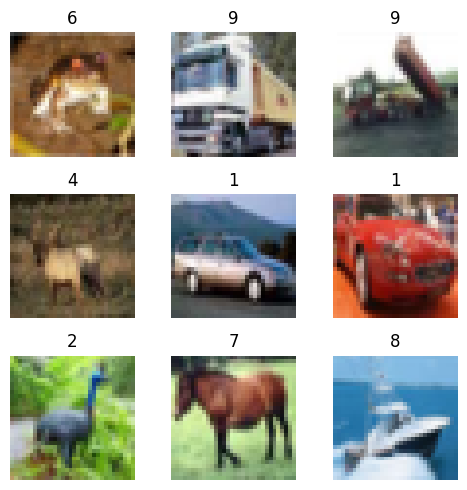

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

### DataLoader

Le `DataLoader` est un itérateur qui découpe le dataset en **mini-batches** et les mélange à chaque époque (`shuffle=True` pour l'entraînement).  
Ici un batch contient 64 images, chacune de forme `[3, 32, 32]` (3 canaux RGB, 32×32 pixels) → batch de forme `[64, 3, 32, 32]`.

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

train_features, train_labels = next(iter(train_dataloader))
train_features.size()

torch.Size([64, 3, 32, 32])

## Création du MLP

Un **MLP** (Multi-Layer Perceptron) est un réseau de neurones entièrement connecté.  
Chaque neurone d'une couche est relié à tous les neurones de la couche suivante.

Architecture utilisée :
```
Entrée : 3072 (= 3 × 32×32 pixels aplatis)
  → Couche 1 : 128 neurones + ReLU
  → Couche 2 : 64 neurones + ReLU
  → Sortie   : 10 neurones (un score par classe)
```

**ReLU** (Rectified Linear Unit) est la fonction d'activation : elle vaut `max(0, x)` et permet au réseau d'apprendre des relations non-linéaires.  
**Softmax** convertit les scores de sortie en probabilités (somme = 1).

In [7]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()              # [B, 3, 32, 32] → [B, 3072]
        self.fc1 = nn.Linear(3*32*32, 128)       # première couche cachée
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)            # deuxième couche cachée
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)             # couche de sortie : 10 classes

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [8]:
mlp = MLP()

print(mlp)

n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"\n[2.3] Paramètres entraînables : {n_params:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

[2.3] Paramètres entraînables : 402,250


On vérifie que le modèle fonctionne en lui passant un tenseur aléatoire de la même forme qu'un vrai batch.

In [9]:
x_dummy = torch.randn(1, 3*32*32)
output = mlp(x_dummy)
print(f"\n[2.4] Forward pass : entrée {x_dummy.shape} -> sortie {output.shape}")
print(f"Sortie : {output}")


[2.4] Forward pass : entrée torch.Size([1, 3072]) -> sortie torch.Size([1, 10])
Sortie : tensor([[-0.0643,  0.2039, -0.0689,  0.0448,  0.0447, -0.0159,  0.1534,  0.0531,
         -0.0905, -0.1550]], grad_fn=<AddmmBackward0>)


## Entraînement

L'entraînement d'un réseau de neurones repose sur deux éléments :

- **Fonction de perte** (`CrossEntropyLoss`) : mesure l'écart entre la prédiction du modèle et la vraie étiquette. L'objectif est de la minimiser.
- **Optimiseur** (`AdamW`, lr=0.001) : met à jour les poids du réseau après chaque batch en suivant le gradient de la perte. AdamW est une variante efficace de la descente de gradient.

L'entraînement alterne entre deux phases à chaque **époque** (passage complet sur le dataset) :
1. `train_loop` — le modèle apprend en ajustant ses poids
2. `test_loop` — le modèle est évalué sans mise à jour des poids (`torch.no_grad()`)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)

In [11]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()  # active le mode entraînement (dropout, batchnorm se comportent différemment)
    for batch, (x, y_true) in enumerate(dataloader):
        y_pred = model(x)
        loss = loss_fn(y_pred, y_true)

        # Rétropropagation : calcule les gradients puis met à jour les poids
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # remet les gradients à zéro pour le prochain batch

        if batch % 100 == 0:
            loss, current = loss.item(), batch * 64 + len(x)
            print(f"loss : {loss:.4f} [{current:>5d} / {size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()  # désactive le mode entraînement
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():  # pas de calcul de gradients en évaluation (plus rapide)
        for x, y_true in dataloader:
            y_pred = model(x)
            test_loss += loss_fn(y_pred, y_true).item()
            # argmax(1) : prend l'indice du score le plus élevé parmi les 10 classes
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size

    print(f"Test error : Accuracy: {100 * correct:>0.1f}%, Avg loss : {test_loss:>8f}")

In [12]:
epochs = 10

for t in range(epochs):
    print("Epoch :", t+1)
    train_loop(train_dataloader, mlp, criterion, optimizer)
    test_loop(test_dataloader, mlp, criterion)

print("Done")

Epoch : 1
loss : 2.3043 [   64 / 50000]
loss : 2.0289 [ 6464 / 50000]
loss : 1.9527 [12864 / 50000]
loss : 1.9718 [19264 / 50000]
loss : 1.8260 [25664 / 50000]
loss : 1.9045 [32064 / 50000]
loss : 1.9586 [38464 / 50000]
loss : 1.6146 [44864 / 50000]
Test error : Accuracy: 38.4%, Avg loss : 1.720836
Epoch : 2
loss : 1.7374 [   64 / 50000]
loss : 1.6251 [ 6464 / 50000]
loss : 1.9933 [12864 / 50000]
loss : 1.6246 [19264 / 50000]
loss : 1.7419 [25664 / 50000]
loss : 1.6003 [32064 / 50000]
loss : 1.5772 [38464 / 50000]
loss : 1.7497 [44864 / 50000]
Test error : Accuracy: 40.2%, Avg loss : 1.666850
Epoch : 3
loss : 1.7245 [   64 / 50000]
loss : 1.9119 [ 6464 / 50000]
loss : 1.4946 [12864 / 50000]
loss : 1.4120 [19264 / 50000]
loss : 1.7343 [25664 / 50000]
loss : 1.5995 [32064 / 50000]
loss : 1.7461 [38464 / 50000]
loss : 1.6778 [44864 / 50000]
Test error : Accuracy: 44.1%, Avg loss : 1.582021
Epoch : 4
loss : 1.6564 [   64 / 50000]
loss : 1.7136 [ 6464 / 50000]
loss : 1.5115 [12864 / 50000]
